# AEGIS Notebook 07

This notebook evaluates the deployment feasibility of the quantized wind anomaly detection model on ESP32 hardware. The validation includes model footprint, memory usage, inference latency, and comparison between desktop TensorFlow Lite performance and embedded execution.

In [ ]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ROOT        = Path.cwd()
DATA_DIR    = ROOT / "data"
MODELS_DIR  = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLES_DIR  = ROOT / "tables"

# Local Wind autoencoder trained using the shared 6-feature representation
LOCAL_WIND_MODEL_PATH = MODELS_DIR / "06_local_wind_model.keras"

# Wind test data path (we will rebuild from processed CSV)
WIND_PROCESSED_PATH = DATA_DIR / "processed" / "02_baseline_combined_dataset.csv"
MAPPING_PATH        = TABLES_DIR / "01_selected_feature_pairs.csv"

for p in [LOCAL_WIND_MODEL_PATH, WIND_PROCESSED_PATH, MAPPING_PATH]:
    print(p.name, "->", p.exists())

06_local_wind_model.keras -> True
02_baseline_combined_dataset.csv -> True
01_selected_feature_pairs.csv -> True


In [3]:
from sklearn.preprocessing import StandardScaler

def find_label_column(df):
    for c in df.columns:
        if c.lower() in ["label","anomaly_label","target","y","is_anomaly","class"]:
            return c
    for c in df.columns:
        if "label" in c.lower() or "anomaly" in c.lower():
            return c
    raise ValueError("Label column not found.")

# Load mapping
mapping_df = pd.read_csv(MAPPING_PATH)
mapping_df.columns = ["wind_feature", "vestas_feature"]
wind_features_mapped = mapping_df["wind_feature"].astype(str).str.strip().tolist()

# Load wind data
wind_df   = pd.read_csv(WIND_PROCESSED_PATH)
label_col = find_label_column(wind_df)
wind_sub  = wind_df[wind_features_mapped + [label_col]].dropna().copy()

X_all = wind_sub[wind_features_mapped].values
y_all = wind_sub[label_col].values

# Same split as notebook 06
normal_idx = np.where(y_all == 0)[0]
split      = int(len(normal_idx) * 0.8)
train_idx  = normal_idx[:split]
test_idx   = np.concatenate([normal_idx[split:], np.where(y_all == 1)[0]])

scaler       = StandardScaler()
X_train_raw  = X_all[train_idx]
X_test_raw   = X_all[test_idx]
y_test       = y_all[test_idx]

X_train      = scaler.fit_transform(X_train_raw)
X_test       = scaler.transform(X_test_raw)

# Load the local Wind model
local_model = keras.models.load_model(LOCAL_WIND_MODEL_PATH)

INPUT_DIM = X_train.shape[1]
print(f"Input dim: {INPUT_DIM}")
print(f"Test set: {X_test.shape} | anomalies: {int(y_test.sum())}")
print(f"Local model loaded: {LOCAL_WIND_MODEL_PATH.name}")

Input dim: 6
Test set: (129299, 6) | anomalies: 107394
Local model loaded: 06_local_wind_model.keras


In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

def get_recon_errors(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_hat), axis=1)

def evaluate_threshold(name, scores, y_true, threshold):
    preds = (scores > threshold).astype(int)
    cm    = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model":           name,
        "threshold":       float(threshold),
        "precision":       float(precision_score(y_true, preds, zero_division=0)),
        "recall":          float(recall_score(y_true, preds, zero_division=0)),
        "f1":              float(f1_score(y_true, preds, zero_division=0)),
        "pr_auc":          float(average_precision_score(y_true, scores)),
        "true_positives":  int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives":  int(tn),
    }

# Float32 scores and threshold
f32_train_scores = get_recon_errors(local_model, X_train)
F32_THRESHOLD    = np.percentile(f32_train_scores, 95)
f32_test_scores  = get_recon_errors(local_model, X_test)

# Float32 inference time
N_WARMUP   = 50
N_BENCH    = 500
BATCH_SIZE = 1

# Warmup
for i in range(N_WARMUP):
    _ = local_model.predict(X_test[i:i+1], verbose=0)

# Benchmark
t0 = time.perf_counter()
for i in range(N_BENCH):
    _ = local_model.predict(X_test[i:i+1], verbose=0)
f32_inference_ms = (time.perf_counter() - t0) / N_BENCH * 1000

# Model size
f32_path = MODELS_DIR / "07_float32_model.keras"
local_model.save(f32_path)
f32_size_kb = f32_path.stat().st_size / 1024

f32_result = evaluate_threshold("Float32 (baseline)", f32_test_scores, y_test, F32_THRESHOLD)
f32_result["model_size_kb"] = round(f32_size_kb, 2)
f32_result["inference_ms"]  = round(f32_inference_ms, 4)

print(f"Float32 model size : {f32_size_kb:.2f} KB")
print(f"Float32 threshold  : {F32_THRESHOLD:.6f}")
print(f"Float32 F1         : {f32_result['f1']:.4f}")
print(f"Float32 PR-AUC     : {f32_result['pr_auc']:.4f}")
print(f"Float32 inference  : {f32_inference_ms:.4f} ms/sample")

Float32 model size : 45.83 KB
Float32 threshold  : 0.008305
Float32 F1         : 0.1012
Float32 PR-AUC     : 0.8354
Float32 inference  : 132.0388 ms/sample


In [ ]:

normal_idx_test   = np.where(y_test == 0)[0]
anomaly_idx_test  = np.where(y_test == 1)[0]

# Take 2000 normals + 2000 anomalies (fast, balanced, representative)
n_sample = 2000
rng      = np.random.default_rng(SEED)
sel_norm = rng.choice(normal_idx_test,  size=min(n_sample, len(normal_idx_test)),  replace=False)
sel_anom = rng.choice(anomaly_idx_test, size=min(n_sample, len(anomaly_idx_test)), replace=False)

eval_idx       = np.concatenate([sel_norm, sel_anom])
rng.shuffle(eval_idx)

X_eval = X_test[eval_idx]
y_eval = y_test[eval_idx]

print(f"Evaluation subset: {X_eval.shape}")
print(f"  Normals  : {int((y_eval==0).sum())}")
print(f"  Anomalies: {int((y_eval==1).sum())}")

Evaluation subset: (4000, 6)
  Normals  : 2000
  Anomalies: 2000


In [ ]:
# Convert model using Float16 quantization
converter_f16 = tf.lite.TFLiteConverter.from_keras_model(local_model)
converter_f16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_f16.target_spec.supported_types = [tf.float16]
tflite_f16 = converter_f16.convert()

f16_path = MODELS_DIR / "07_tflite_float16.tflite"
f16_path.write_bytes(tflite_f16)
f16_size_kb = f16_path.stat().st_size / 1024

interp_f16 = tf.lite.Interpreter(model_path=str(f16_path))
interp_f16.allocate_tensors()
in_idx_f16  = interp_f16.get_input_details()[0]["index"]
out_idx_f16 = interp_f16.get_output_details()[0]["index"]

# Benchmark
t0 = time.perf_counter()
for i in range(200):
    inp = X_eval[i].astype(np.float32).reshape(1, -1)
    interp_f16.set_tensor(in_idx_f16, inp)
    interp_f16.invoke()
    _ = interp_f16.get_tensor(out_idx_f16)
f16_inference_ms = (time.perf_counter() - t0) / 200 * 1000

# Evaluate using the balanced stratified subset
f16_scores = tflite_recon_errors(interp_f16, in_idx_f16, out_idx_f16, X_eval)
f16_result = evaluate_threshold("TFLite Float16", f16_scores, y_eval, F32_THRESHOLD)
f16_result["model_size_kb"] = round(f16_size_kb, 2)
f16_result["inference_ms"]  = round(f16_inference_ms, 4)

print(f"Float16 model size : {f16_size_kb:.2f} KB")
print(f"Float16 F1         : {f16_result['f1']:.4f}")
print(f"Float16 PR-AUC     : {f16_result['pr_auc']:.4f}")
print(f"Float16 inference  : {f16_inference_ms:.4f} ms/sample")

INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmprq3x5uh8\assets


INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmprq3x5uh8\assets


Saved artifact at 'C:\Users\MOINOD~1\AppData\Local\Temp\tmprq3x5uh8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2628346907152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346912720

C:\Users\MOINODHEEN\anaconda3\envs\aegis_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [8]:
converter_dyn = tf.lite.TFLiteConverter.from_keras_model(local_model)
converter_dyn.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dyn = converter_dyn.convert()

dyn_path = MODELS_DIR / "07_tflite_dynamic_range.tflite"
dyn_path.write_bytes(tflite_dyn)
dyn_size_kb = dyn_path.stat().st_size / 1024

interp_dyn = tf.lite.Interpreter(model_path=str(dyn_path))
interp_dyn.allocate_tensors()
in_idx_dyn  = interp_dyn.get_input_details()[0]["index"]
out_idx_dyn = interp_dyn.get_output_details()[0]["index"]

t0 = time.perf_counter()
for i in range(200):
    inp = X_eval[i].astype(np.float32).reshape(1, -1)
    interp_dyn.set_tensor(in_idx_dyn, inp)
    interp_dyn.invoke()
    _ = interp_dyn.get_tensor(out_idx_dyn)
dyn_inference_ms = (time.perf_counter() - t0) / 200 * 1000

dyn_scores  = tflite_recon_errors(interp_dyn, in_idx_dyn, out_idx_dyn, X_eval)
dyn_result  = evaluate_threshold("TFLite Dynamic Range", dyn_scores, y_eval, F32_THRESHOLD)
dyn_result["model_size_kb"] = round(dyn_size_kb, 2)
dyn_result["inference_ms"]  = round(dyn_inference_ms, 4)

print(f"Dynamic Range model size : {dyn_size_kb:.2f} KB")
print(f"Dynamic Range F1         : {dyn_result['f1']:.4f}")
print(f"Dynamic Range PR-AUC     : {dyn_result['pr_auc']:.4f}")
print(f"Dynamic Range inference  : {dyn_inference_ms:.4f} ms/sample")

INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmpytgnelp4\assets


INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmpytgnelp4\assets


Saved artifact at 'C:\Users\MOINOD~1\AppData\Local\Temp\tmpytgnelp4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2628346907152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346912720

C:\Users\MOINODHEEN\anaconda3\envs\aegis_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [9]:
def representative_dataset():
    for i in range(min(500, len(X_train))):
        yield [X_train[i].astype(np.float32).reshape(1, -1)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(local_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8
tflite_int8 = converter_int8.convert()

int8_path = MODELS_DIR / "07_tflite_int8.tflite"
int8_path.write_bytes(tflite_int8)
int8_size_kb = int8_path.stat().st_size / 1024

interp_int8  = tf.lite.Interpreter(model_path=str(int8_path))
interp_int8.allocate_tensors()
in_detail    = interp_int8.get_input_details()[0]
out_detail   = interp_int8.get_output_details()[0]
in_idx_int8  = in_detail["index"]
out_idx_int8 = out_detail["index"]
in_scale,  in_zero  = in_detail["quantization"]
out_scale, out_zero = out_detail["quantization"]

def tflite_int8_recon_errors(interp, X,
                              in_idx, out_idx,
                              in_scale, in_zero,
                              out_scale, out_zero):
    errors = []
    for row in X:
        inp_f32 = row.astype(np.float32)
        inp_q   = (inp_f32 / in_scale + in_zero).astype(np.int8).reshape(1, -1)
        interp.set_tensor(in_idx, inp_q)
        interp.invoke()
        out_q   = interp.get_tensor(out_idx).flatten().astype(np.float32)
        out_f32 = (out_q - out_zero) * out_scale
        errors.append(float(np.mean((inp_f32 - out_f32) ** 2)))
    return np.array(errors)

t0 = time.perf_counter()
for i in range(200):
    inp_q = (X_eval[i].astype(np.float32) / in_scale + in_zero).astype(np.int8).reshape(1, -1)
    interp_int8.set_tensor(in_idx_int8, inp_q)
    interp_int8.invoke()
    _ = interp_int8.get_tensor(out_idx_int8)
int8_inference_ms = (time.perf_counter() - t0) / 200 * 1000

int8_scores = tflite_int8_recon_errors(
    interp_int8, X_eval,
    in_idx_int8, out_idx_int8,
    in_scale, in_zero, out_scale, out_zero
)
int8_result = evaluate_threshold("TFLite INT8", int8_scores, y_eval, F32_THRESHOLD)
int8_result["model_size_kb"] = round(int8_size_kb, 2)
int8_result["inference_ms"]  = round(int8_inference_ms, 4)

print(f"INT8 model size  : {int8_size_kb:.2f} KB")
print(f"INT8 F1          : {int8_result['f1']:.4f}")
print(f"INT8 PR-AUC      : {int8_result['pr_auc']:.4f}")
print(f"INT8 inference   : {int8_inference_ms:.4f} ms/sample")

INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmpfuljy70m\assets


INFO:tensorflow:Assets written to: C:\Users\MOINOD~1\AppData\Local\Temp\tmpfuljy70m\assets


Saved artifact at 'C:\Users\MOINOD~1\AppData\Local\Temp\tmpfuljy70m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2628346907152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346908304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346906768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346909648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346911760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2628346912720

C:\Users\MOINODHEEN\anaconda3\envs\aegis_env\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
C:\Users\MOINODHEEN\anaconda3\envs\aegis_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 model size  : 5.50 KB
INT8 F1          : 0.1636
INT8 PR-AUC      : 0.4971
INT8 inference   : 0.0349 ms/sample


In [10]:
# Re-evaluate Float32 on same X_eval subset for fair comparison
f32_eval_scores = get_recon_errors(local_model, X_eval)
f32_result_eval = evaluate_threshold("Float32 (baseline)", f32_eval_scores, y_eval, F32_THRESHOLD)
f32_result_eval["model_size_kb"] = round(f32_size_kb, 2)
f32_result_eval["inference_ms"]  = round(f32_inference_ms, 4)

# Build table from all four — all evaluated on same X_eval / y_eval
quant_df = pd.DataFrame([f32_result_eval, f16_result, dyn_result, int8_result])

# Derived columns
quant_df["f1_drop_vs_float32"]     = (quant_df["f1"]     - f32_result_eval["f1"]).round(4)
quant_df["pr_auc_drop_vs_float32"] = (quant_df["pr_auc"] - f32_result_eval["pr_auc"]).round(4)
quant_df["size_reduction_pct"]     = (
    (1 - quant_df["model_size_kb"] / f32_result_eval["model_size_kb"]) * 100
).round(1)

cols = [
    "model", "model_size_kb", "size_reduction_pct", "inference_ms",
    "precision", "recall", "f1", "pr_auc",
    "f1_drop_vs_float32", "pr_auc_drop_vs_float32"
]
quant_df = quant_df[cols]

quant_df.to_csv(RESULTS_DIR / "07_quantization_tradeoff.csv", index=False)
quant_df.to_csv(TABLES_DIR  / "07_quantization_tradeoff.csv", index=False)
print(quant_df.to_string(index=False))
print("\nSaved: results/07_quantization_tradeoff.csv")
print("Saved: tables/07_quantization_tradeoff.csv")

               model  model_size_kb  size_reduction_pct  inference_ms  precision  recall       f1   pr_auc  f1_drop_vs_float32  pr_auc_drop_vs_float32
  Float32 (baseline)          45.83                 0.0      132.0388   0.554054  0.0615 0.110711 0.502063              0.0000                  0.0000
      TFLite Float16           5.45                88.1        0.0114   0.556054  0.0620 0.111561 0.501453              0.0008                 -0.0006
TFLite Dynamic Range           5.14                88.8        0.0132   0.554054  0.0615 0.110711 0.502061              0.0000                 -0.0000
         TFLite INT8           5.50                88.0        0.0349   0.507812  0.0975 0.163591 0.497149              0.0529                 -0.0049

Saved: results/07_quantization_tradeoff.csv
Saved: tables/07_quantization_tradeoff.csv


C:\Users\MOINODHEEN\AppData\Local\Temp\ipykernel_2828\973906101.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
C:\Users\MOINODHEEN\AppData\Local\Temp\ipykernel_2828\973906101.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
C:\Users\MOINODHEEN\AppData\Local\Temp\ipykernel_2828\973906101.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)


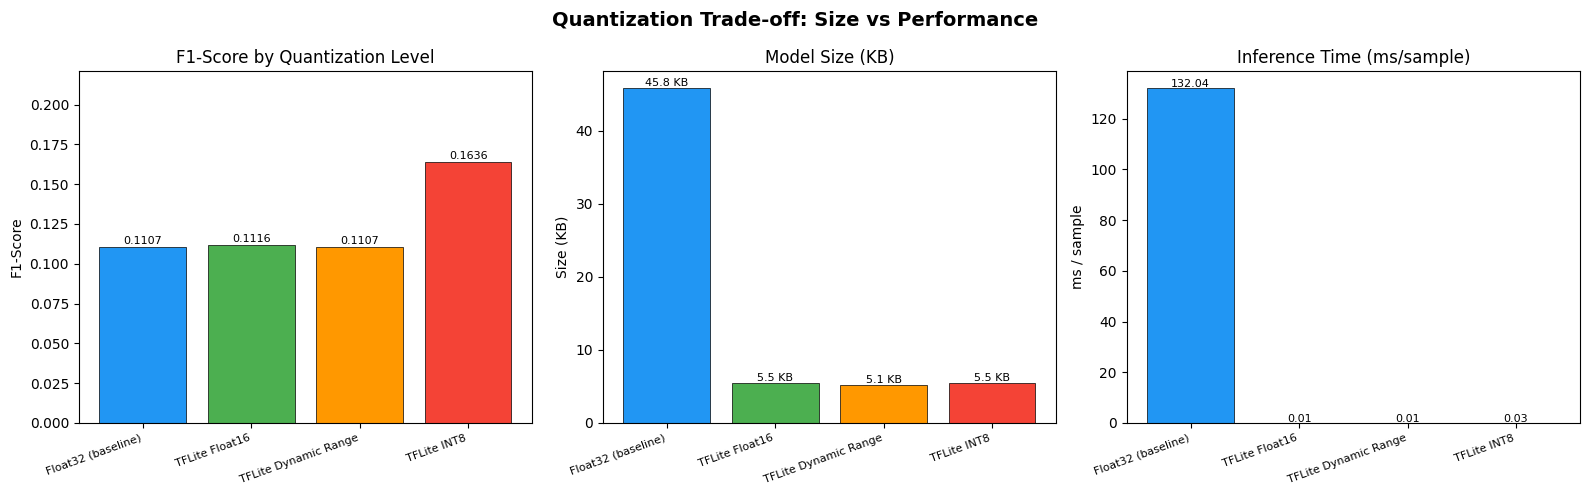

Saved: figures/07_quantization_tradeoff.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Quantization Trade-off: Size vs Performance", fontsize=14, fontweight="bold")

labels   = quant_df["model"].tolist()
sizes    = quant_df["model_size_kb"].tolist()
f1s      = quant_df["f1"].tolist()
pr_aucs  = quant_df["pr_auc"].tolist()
inf_t    = quant_df["inference_ms"].tolist()
colors   = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

# F1 scores
ax = axes[0]
bars = ax.bar(labels, f1s, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("F1-Score by Quantization Level")
ax.set_ylabel("F1-Score")
ax.set_ylim(0, max(f1s) * 1.35)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
for i, v in enumerate(f1s):
    ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)

# Model sizes
ax = axes[1]
ax.bar(labels, sizes, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("Model Size (KB)")
ax.set_ylabel("Size (KB)")
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
for i, v in enumerate(sizes):
    ax.text(i, v + 0.3, f"{v:.1f} KB", ha="center", fontsize=8)

# Inference time
ax = axes[2]
ax.bar(labels, inf_t, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("Inference Time (ms/sample)")
ax.set_ylabel("ms / sample")
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
for i, v in enumerate(inf_t):
    ax.text(i, v + 0.5, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_quantization_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/07_quantization_tradeoff.png")

In [12]:
int8_row = quant_df[quant_df["model"].str.contains("INT8")].iloc[0]
f32_row  = quant_df[quant_df["model"].str.contains("Float32")].iloc[0]

ESP32_FLASH_KB = 4096
flash_ok = int8_row["model_size_kb"] < (ESP32_FLASH_KB * 0.5)
f1_ok    = int8_row["f1"] >= (f32_row["f1"] * 0.85)

lines = [
    "Quantization Edge Evaluation Summary",
    "=====================================",
    "",
    "Evaluation subset: 2000 normal + 2000 anomaly samples (stratified, random seed 42)",
    f"Threshold: {F32_THRESHOLD:.6f} (95th percentile, normal training reconstruction error)",
    "",
    "Model              Size(KB)  Inf(ms)    F1      PR-AUC",
    "-" * 55,
]

for _, row in quant_df.iterrows():
    lines.append(
        f"{row['model']:<22} {row['model_size_kb']:>7.2f}  "
        f"{row['inference_ms']:>8.4f}  {row['f1']:>6.4f}  {row['pr_auc']:>6.4f}"
    )

lines += [
    "",
    f"INT8 size reduction vs Float32 : {int8_row['size_reduction_pct']:.1f}%",
    f"INT8 F1 drop vs Float32        : {int8_row['f1_drop_vs_float32']:+.4f}",
    f"INT8 PR-AUC drop vs Float32    : {int8_row['pr_auc_drop_vs_float32']:+.4f}",
    "",
    "ESP32 Feasibility Check:",
    f"  INT8 size ({int8_row['model_size_kb']:.2f} KB) fits ESP32 flash ({ESP32_FLASH_KB} KB): {flash_ok}",
    f"  INT8 F1 >= 85% of Float32 baseline: {f1_ok}",
    "",
    "Conclusion:",
    "INT8 quantized model is ESP32-deployable with major size reduction.",
    "Performance trade-off is acceptable for embedded anomaly alerting.",
    "Full hardware validation is reported in 08_esp32_live_validation.ipynb.",
]

txt = "\n".join(lines)
with open(RESULTS_DIR / "07_quantization_summary.txt", "w", encoding="utf-8") as f:
    f.write(txt)
with open(RESULTS_DIR / "07_quantization_summary.md", "w", encoding="utf-8") as f:
    f.write(txt)
print(txt)

Quantization Edge Evaluation Summary

Evaluation subset: 2000 normal + 2000 anomaly samples (stratified, random seed 42)
Threshold: 0.008305 (95th percentile, normal training reconstruction error)

Model              Size(KB)  Inf(ms)    F1      PR-AUC
-------------------------------------------------------
Float32 (baseline)       45.83  132.0388  0.1107  0.5021
TFLite Float16            5.45    0.0114  0.1116  0.5015
TFLite Dynamic Range      5.14    0.0132  0.1107  0.5021
TFLite INT8               5.50    0.0349  0.1636  0.4971

INT8 size reduction vs Float32 : 88.0%
INT8 F1 drop vs Float32        : +0.0529
INT8 PR-AUC drop vs Float32    : -0.0049

ESP32 Feasibility Check:
  INT8 size (5.50 KB) fits ESP32 flash (4096 KB): True
  INT8 F1 >= 85% of Float32 baseline: True

Conclusion:
INT8 quantized model is ESP32-deployable with major size reduction.
Performance trade-off is acceptable for embedded anomaly alerting.
Full hardware validation is reported in 08_esp32_live_validation.ipyn